In [1]:
#Library
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score



In [2]:
#Constants and Reproducibility
SEED = 42
EPOCHS = 100
LEARNING_RATE = 1e-3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [3]:
#Dataset Loading
df = pd.read_csv("Breast Cancer (Diagnostic) Data Set.csv")

# unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32"])

# Target encoding: B=0, M=1
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

X = df.drop("diagnosis", axis=1).values
y = df["diagnosis"].values


In [4]:
#Train / Validation / Test Split (NO LEAKAGE)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)


In [5]:
#Scaling (FIT ONLY IN TRAIN ❗)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


In [6]:
#Tensor Transform
def to_tensor(x, y):
    return (
        torch.tensor(x, dtype=torch.float32).to(DEVICE),
        torch.tensor(y, dtype=torch.float32).to(DEVICE)
    )

X_train, y_train = to_tensor(X_train, y_train)
X_val, y_val     = to_tensor(X_val, y_val)
X_test, y_test   = to_tensor(X_test, y_test)


In [7]:
#******************Models********************

In [8]:
#Logistic Regression
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)


In [9]:
#MLP
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


In [10]:
#******************Lost Functions********************

In [11]:
#Weighted BCE
pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    device=DEVICE
)


In [12]:
#Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction="none")

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


In [13]:
#Hinge Loss
class HingeLoss(nn.Module):
    def forward(self, logits, targets):
        targets = targets * 2 - 1
        return torch.mean(torch.clamp(1 - logits.squeeze() * targets, min=0))


In [14]:
loss_functions = {
    "BCE": nn.BCEWithLogitsLoss(),
    "Weighted_BCE": nn.BCEWithLogitsLoss(pos_weight=pos_weight),
    "Focal": FocalLoss(),
    "Hinge": HingeLoss()
}


In [15]:
#Training + Validation
def train_model(model, loss_fn):
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    train_losses, val_losses = [], []

    for _ in range(EPOCHS):
        model.train()
        optimizer.zero_grad()

        logits = model(X_train).squeeze()
        loss = loss_fn(logits, y_train)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val).squeeze()
            val_loss = loss_fn(val_logits, y_val)
            val_losses.append(val_loss.item())

    return train_losses, val_losses


In [16]:
#Test Evaluation
def evaluate(model, loss_name):
    model.eval()
    with torch.no_grad():
        logits = model(X_test).squeeze().cpu().numpy()

    y_true = y_test.cpu().numpy()

    if loss_name == "Hinge":
        preds = (logits >= 0).astype(int)
        roc = np.nan
    else:
        probs = 1 / (1 + np.exp(-logits))
        preds = (probs >= 0.5).astype(int)
        roc = roc_auc_score(y_true, probs)

    return {
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds),
        "Recall": recall_score(y_true, preds),
        "F1": f1_score(y_true, preds),
        "ROC_AUC": roc
    }


Training Logistic Regression with BCE


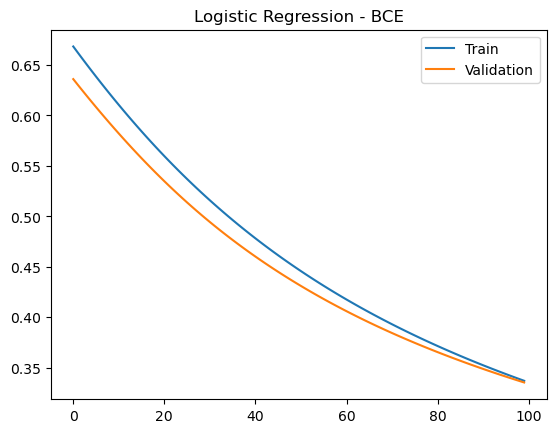

Training Logistic Regression with Weighted_BCE


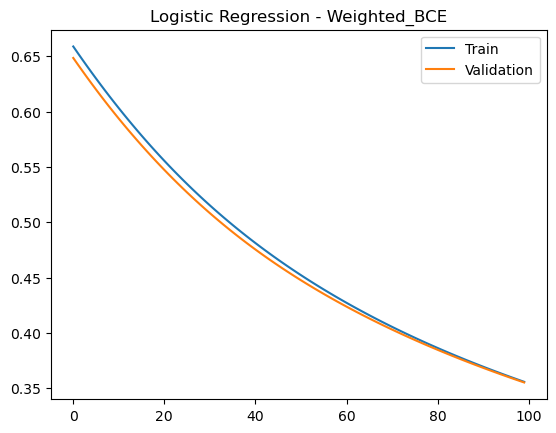

Training Logistic Regression with Focal


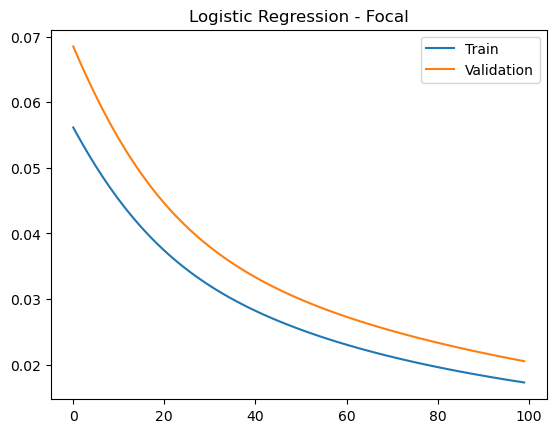

Training Logistic Regression with Hinge


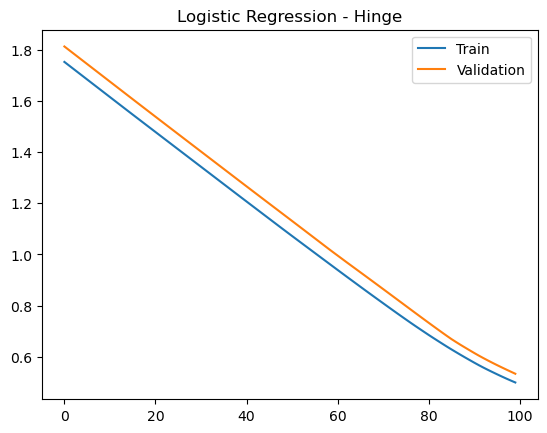

Training MLP with BCE


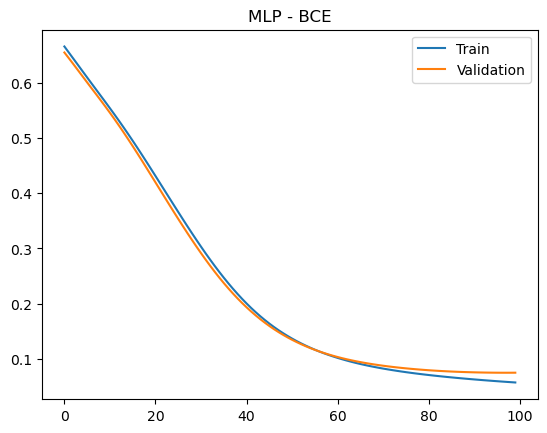

Training MLP with Weighted_BCE


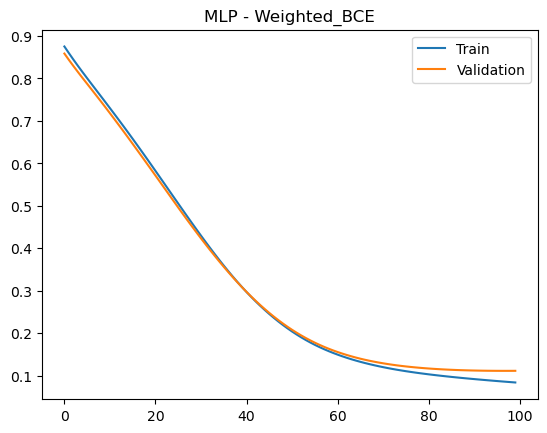

Training MLP with Focal


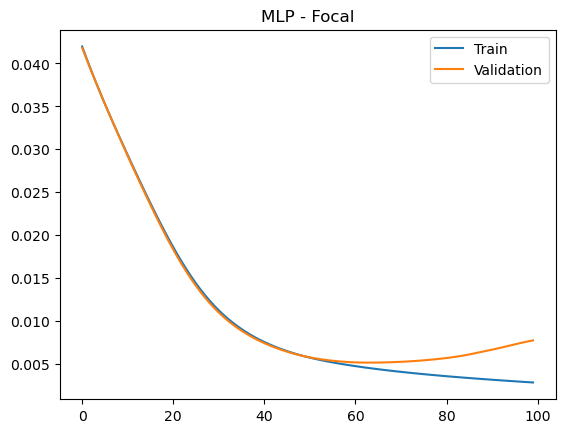

Training MLP with Hinge


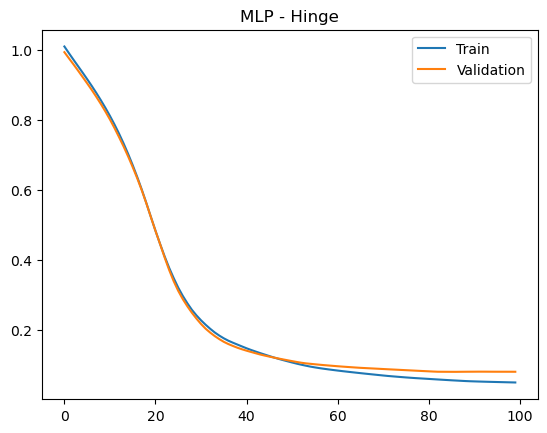

In [17]:
#ALL EXPERIMENTS (2 MODEL × 4 LOSS)
results = []

models = {
    "Logistic Regression": LogisticRegressionModel,
    "MLP": MLP
}

for model_name, model_class in models.items():
    for loss_name, loss_fn in loss_functions.items():
        print(f"Training {model_name} with {loss_name}")

        model = model_class(X_train.shape[1]).to(DEVICE)
        train_l, val_l = train_model(model, loss_fn)
        metrics = evaluate(model, loss_name)

        results.append({
            "Model": model_name,
            "Loss": loss_name,
            **metrics
        })

        plt.plot(train_l, label="Train")
        plt.plot(val_l, label="Validation")
        plt.title(f"{model_name} - {loss_name}")
        plt.legend()
        plt.show()


In [18]:
results_df = pd.DataFrame(results)
results_df


,Model,Loss,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,BCE,0.965116,1.000000,0.90625,0.950820,0.992477
1,Logistic Regression,Weighted_BCE,0.965116,1.000000,0.90625,0.950820,0.997685
2,Logistic Regression,Focal,0.965116,0.914286,1.00000,0.955224,0.999421
3,Logistic Regression,Hinge,0.895349,1.000000,0.71875,0.836364,NaN
4,MLP,BCE,0.988372,1.000000,0.96875,0.984127,1.000000
5,MLP,Weighted_BCE,1.000000,1.000000,1.00000,1.000000,1.000000
6,MLP,Focal,0.988372,1.000000,0.96875,0.984127,1.000000
7,MLP,Hinge,1.000000,1.000000,1.00000,1.000000,NaN
